# Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorboard.plugins.hparams import api as hp
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import MinMaxScaler
import datetime

# Chargement des données

In [4]:
df = pd.read_csv(
    "data/raw/sites/dataclean_prm_30000250086126.csv",
    sep=",",
    decimal="."
)
# Convertir la colonne datetime en format datetime
df['datetime'] = pd.to_datetime(df['datetime'])

# Afficher les informations sur les dates
print("=" * 60)
print("📅 INFORMATIONS SUR LES DATES DU DATASET")
print("=" * 60)
print(f"\n📆 Date la plus ancienne : {df['datetime'].min()}")
print(f"📆 Date la plus récente  : {df['datetime'].max()}")
print(f"\n📊 Nombre total de lignes : {len(df):,}")
print(f"📊 Période couverte       : {(df['datetime'].max() - df['datetime'].min()).days} jours")
print(f"📊 Fréquence              : Horaire (1 ligne par heure)")
print("\n" + "=" * 60)

# Afficher les 5 dernières lignes (données les plus récentes)
print("\n🔍 LES 5 LIGNES LES PLUS RÉCENTES :")
print(df.sort_values('datetime').tail(5))

df.head()

📅 INFORMATIONS SUR LES DATES DU DATASET

📆 Date la plus ancienne : 2023-10-31 00:00:00
📆 Date la plus récente  : 2026-03-30 23:55:00

📊 Nombre total de lignes : 236,349
📊 Période couverte       : 881 jours
📊 Fréquence              : Horaire (1 ligne par heure)


🔍 LES 5 LIGNES LES PLUS RÉCENTES :
                   prm                ville  puissance            datetime  \
236344  30000250086126  Juvigny les Vallées   217000.0 2026-03-30 23:35:00   
236345  30000250086126  Juvigny les Vallées   223000.0 2026-03-30 23:40:00   
236346  30000250086126  Juvigny les Vallées   215000.0 2026-03-30 23:45:00   
236347  30000250086126  Juvigny les Vallées   223000.0 2026-03-30 23:50:00   
236348  30000250086126  Juvigny les Vallées   228000.0 2026-03-30 23:55:00   

        id_site  code_postal  temperature  humidite  precipitation  \
236344      9.0        50520          6.8      79.0            0.0   
236345      9.0        50520          6.8      79.0            0.0   
236346      9.0        

,prm,ville,puissance,datetime,id_site,code_postal,temperature,humidite,precipitation,vitesse_vent,direction_vent,couverture_nuages
0,30000250086126,Juvigny les Vallées,230000.0,2023-10-31 00:00:00,9.0,50520,8.4,94.0,0.0,10.6,156.0,98.0
1,30000250086126,Juvigny les Vallées,228000.0,2023-10-31 00:05:00,9.0,50520,8.4,94.0,0.0,10.6,156.0,98.0
2,30000250086126,Juvigny les Vallées,208000.0,2023-10-31 00:10:00,9.0,50520,8.4,94.0,0.0,10.6,156.0,98.0
3,30000250086126,Juvigny les Vallées,209000.0,2023-10-31 00:15:00,9.0,50520,8.4,94.0,0.0,10.6,156.0,98.0
4,30000250086126,Juvigny les Vallées,204000.0,2023-10-31 00:20:00,9.0,50520,8.4,94.0,0.0,10.6,156.0,98.0


In [7]:
# -----------------------
# Feature Engineering avancé
# -----------------------

# 🔧 CONVERSION EN kW (plus lisible)
# Les données sont en Wh, on convertit en kW
df["puissance"] = df["puissance"] / 1000

# Extraire les composantes temporelles
df["heure"] = pd.to_datetime(df["datetime"]).dt.hour
df["mois"] = pd.to_datetime(df["datetime"]).dt.month

# 🔥 Features cycliques pour l'heure (capture mieux les cycles jour/nuit)
df["heure_sin"] = np.sin(2 * np.pi * df["heure"] / 24)
df["heure_cos"] = np.cos(2 * np.pi * df["heure"] / 24)

# Lags de la puissance (heures précédentes)
df["puissance_lag_1"] = df["puissance"].shift(1)
df["puissance_lag_2"] = df["puissance"].shift(2)
df["puissance_lag_3"] = df["puissance"].shift(3)
df["puissance_lag_24"] = df["puissance"].shift(24)  # Même heure hier
df["puissance_lag_48"] = df["puissance"].shift(48)  # Avant-hier (au lieu de 168)

# Moyennes glissantes
df["puissance_roll_3"] = df["puissance"].shift(1).rolling(3).mean()
df["puissance_roll_6"] = df["puissance"].shift(1).rolling(6).mean()
df["puissance_roll_12"] = df["puissance"].shift(1).rolling(12).mean()
df["puissance_roll_24"] = df["puissance"].shift(1).rolling(24).mean()

# Écart-type roulant (variabilité)
df["puissance_std_12"] = df["puissance"].shift(1).rolling(12).std()
df["puissance_std_24"] = df["puissance"].shift(1).rolling(24).std()

# Min/Max roulant (range de variation)
df["puissance_min_24"] = df["puissance"].shift(1).rolling(24).min()
df["puissance_max_24"] = df["puissance"].shift(1).rolling(24).max()

# Interaction température x heure (plus précis avec features cycliques)
df["temp_x_heure_sin"] = df["temperature"] * df["heure_sin"]
df["temp_x_heure_cos"] = df["temperature"] * df["heure_cos"]

df = df.dropna()

print(f"✅ Données converties en kW avec features cycliques")
print(f"   Plage : {df['puissance'].min():.2f} - {df['puissance'].max():.2f} kW")
print(f"   Moyenne : {df['puissance'].mean():.2f} kW")
print(f"   Nombre de features : {len([c for c in df.columns if c != 'puissance'])}")

✅ Données converties en kW avec features cycliques
   Plage : 0.01 - 0.70 kW
   Moyenne : 0.27 kW
   Nombre de features : 30


In [12]:
df.head()

,prm,ville,puissance,id_site,code_postal,temperature,humidite,precipitation,vitesse_vent,direction_vent,...,puissance_roll_3,puissance_roll_6,puissance_roll_12,puissance_roll_24,puissance_std_12,puissance_std_24,puissance_min_24,puissance_max_24,temp_x_heure_sin,temp_x_heure_cos
datetime,,,,,,,,,,,,,,,,,,,,,
2023-10-31 04:00:00,30000250086126,Juvigny les Vallées,0.221,9.0,50520,8.1,98.0,0.0,8.0,216.0,...,0.199333,0.205833,0.202583,0.200042,0.009040,0.010398,0.177,0.221,7.014806,4.05
2023-10-31 04:05:00,30000250086126,Juvigny les Vallées,0.217,9.0,50520,8.1,98.0,0.0,8.0,216.0,...,0.209000,0.207667,0.204833,0.200250,0.010017,0.010775,0.177,0.221,7.014806,4.05
2023-10-31 04:10:00,30000250086126,Juvigny les Vallées,0.223,9.0,50520,8.1,98.0,0.0,8.0,216.0,...,0.216333,0.207000,0.205750,0.200583,0.010618,0.011174,0.177,0.221,7.014806,4.05
2023-10-31 04:15:00,30000250086126,Juvigny les Vallées,0.223,9.0,50520,8.1,98.0,0.0,8.0,216.0,...,0.220333,0.209833,0.207500,0.201042,0.011627,0.011867,0.177,0.223,7.014806,4.05
2023-10-31 04:20:00,30000250086126,Juvigny les Vallées,0.214,9.0,50520,8.1,98.0,0.0,8.0,216.0,...,0.221000,0.215000,0.210083,0.202083,0.011309,0.012659,0.177,0.223,7.014806,4.05


In [21]:


# Définition de la cible et des features
target = "puissance"

features = [
    # Features météo
    "temperature",
    "humidite",
    "vitesse_vent",
    "couverture_nuages",

    # Features temporelles CYCLIQUES (meilleure capture des patterns)
    "heure_sin",
    "heure_cos",

    # Lags courts et moyens (on retire lag_168 qui est trop loin)
    "puissance_lag_1",
    "puissance_lag_2",
    "puissance_lag_3",
    "puissance_lag_24",
    "puissance_lag_48",

    # Moyennes glissantes multiples échelles
    "puissance_roll_3",
    "puissance_roll_6",
    "puissance_roll_12",
    "puissance_roll_24",

    # Variabilité
    "puissance_std_12",
    "puissance_std_24",

    # Min/Max (range)
    "puissance_min_24",
    "puissance_max_24",

    # Interactions avec cycles
    "temp_x_heure_sin",
    "temp_x_heure_cos"
]

X = df[features]
y = df[target]

# 🔥 StandardScaler au lieu de MinMaxScaler (mieux pour les données avec outliers)
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Fonction pour créer les séquences temporelles
def create_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

# Plus simple: fenêtre plus courte
WINDOW = 24
X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW)

split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

model = Sequential([
    LSTM(16, input_shape=(WINDOW, X_seq.shape[2])),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1, verbose=1)

y_pred = scaler_y.inverse_transform(model.predict(X_test, verbose=0))
y_true = scaler_y.inverse_transform(y_test)

# Évaluation
y_pred_scaled = model.predict(X_test, verbose=0)

y_pred = np.clip(y_pred, 0, None)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

eps = 1e-8
mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100
r2 = r2_score(y_true, y_pred)

print(f"\nMAE  : {mae:.2f} kW")
print(f"RMSE : {rmse:.2f} kW")
print(f"MAPE : {mape:.2f} %")
print(f"R²   : {r2:.4f}")

\\?\C:\venv\tf\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - loss: 0.0436 - mae: 0.1248 - val_loss: 0.0145 - val_mae: 0.0827
Epoch 2/10
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 0.0169 - mae: 0.0908 - val_loss: 0.0133 - val_mae: 0.0806
Epoch 3/10
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.0156 - mae: 0.0876 - val_loss: 0.0116 - val_mae: 0.0731
Epoch 4/10
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 0.0150 - mae: 0.0860 - val_loss: 0.0120 - val_mae: 0.0716
Epoch 5/10
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.0146 - mae: 0.0851 - val_loss: 0.0111 - val_mae: 0.0706
Epoch 6/10
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.0143 - mae: 0.0844 - val_loss: 0.0105 - val_mae: 0.0695
Epoch 7/10
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 0.0141 - mae: 0.0838 - val_loss: 0.0104 - val_mae: 0.0697
Epoch 8/10
2659/2659 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - loss: 0.0139 - mae: 0.0832 - val_loss: 0.0107 - val_mae: 0.0710
Epoch 9/10
2659/2659 ━━━━━━━━━━

NameError: name 'nb_negative' is not defined

In [20]:
# df["datetime"] = pd.to_datetime(df["datetime"])       # conversion en format datetime
# df = df.sort_values("datetime")                   # tri chronologique
# df = df.set_index("datetime")                     # mettre la date comme index


# log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# tensorboard_cb = TensorBoard(
#                     log_dir=log_dir,
#                     histogram_freq=1
#                 )

# # Définition de la cible et des features
# target = "puissance"                # variable à prédire

# features = [
#     "temperature",
#     # "humidite",
#     "precipitation",
#     # "vitesse_vent",
#     # "direction_vent",
#     # "couverture_nuages",
#     "jour_semaine",
#     # "mois",
#     # "weekend",
#     # "jour_ferie",
#     "puissance_lag_1",
#     "puissance_lag_2",
#     "puissance_lag_3",
#     "puissance_roll_3"
# ]

# # X = features, y = target
# X = df[features]
# y = df[target]

# # Normalisation (important pour LSTM)
# scaler_X = MinMaxScaler()
# scaler_y = MinMaxScaler()

# X_scaled = scaler_X.fit_transform(X)
# y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# # Fonction pour créer les séquences temporelles
# def create_sequences(X, y, window):
#     """
#     Transforme les données tabulaires en séquences pour LSTM.
#     Chaque séquence contient 'window' jours d'observations pour prédire le jour suivant.
#     """
#     Xs, ys = [], []
#     for i in range(len(X) - window):
#         Xs.append(X[i:i+window])     # X = séquence des 'window' jours
#         ys.append(y[i+window])       # y = valeur du jour suivant
#     return np.array(Xs), np.array(ys)

# # Définir la taille de la fenêtre temporelle
# WINDOW = 7    # LSTM regarde 7 jours pour prédire le 8ème

# # Créer les séquences
# X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW)


# # Séparer les données en train et test
# split = int(0.80 * len(X_seq))     # 80% train, 20% test

# X_train, X_test = X_seq[:split], X_seq[split:]
# y_train, y_test = y_seq[:split], y_seq[split:]


# # Définition du modèle LSTM
# model = Sequential([
#     LSTM(64, return_sequences=True, input_shape=(WINDOW, X_seq.shape[2])),
#     LSTM(32),
#     Dense(1)
# ])

# # Compilation du modèle
# model.compile(
#     optimizer="adam",   # optimiseur efficace pour la régression
#     loss="mse"          # erreur quadratique moyenne (MSE)
# )

# # Afficher le résumé du modèle
# print(model.summary())

# # Hyperparamètres du modèle
# HP_LR = hp.HParam("learning_rate", hp.Discrete([0.001]))
# HP_BATCH_SIZE = hp.HParam("batch_size", hp.Discrete([8]))
# HP_WINDOW = hp.HParam("window", hp.Discrete([7]))
# HP_LSTM1 = hp.HParam("lstm_units_1", hp.Discrete([64]))
# HP_LSTM2 = hp.HParam("lstm_units_2", hp.Discrete([32]))
# HP_EPOCHS = hp.HParam("epochs", hp.Discrete([50]))
# HP_FEATURES = hp.HParam("features", hp.Discrete([",".join(features)]))

# with tf.summary.create_file_writer(log_dir).as_default():
#     hp.hparams({HP_FEATURES: ",".join(features)})

# # EarlyStopping : Évite de trop entraîner le modèle et conserve les meilleurs poids
# early_stop = EarlyStopping(
#     monitor="val_loss",
#     patience=10,           # stop si val_loss n’améliore pas pendant 5 epochs
#     restore_best_weights=True
# )

# # Entrainement du modèle
# history = model.fit(
#     X_train, y_train,
#     epochs=50,
#     batch_size=8,
#     validation_split=0.2,
#     callbacks=[early_stop, tensorboard_cb]
# )

# # Prédiction sur les données de test
# y_pred_scaled = model.predict(X_test)  # prédictions normalisées

# # Revenir aux unités réelles
# y_pred = scaler_y.inverse_transform(y_pred_scaled)  # prédictions en kW
# y_true = scaler_y.inverse_transform(y_test)         # valeurs réelles en kW

# # Calcul de la MAE (erreur moyenne absolue)
# mae = mean_absolute_error(y_true, y_pred)
# print(f"MAE (puissance_moy_jour) : {mae:.2f}")      # affichage clair


# Diagnostic des données

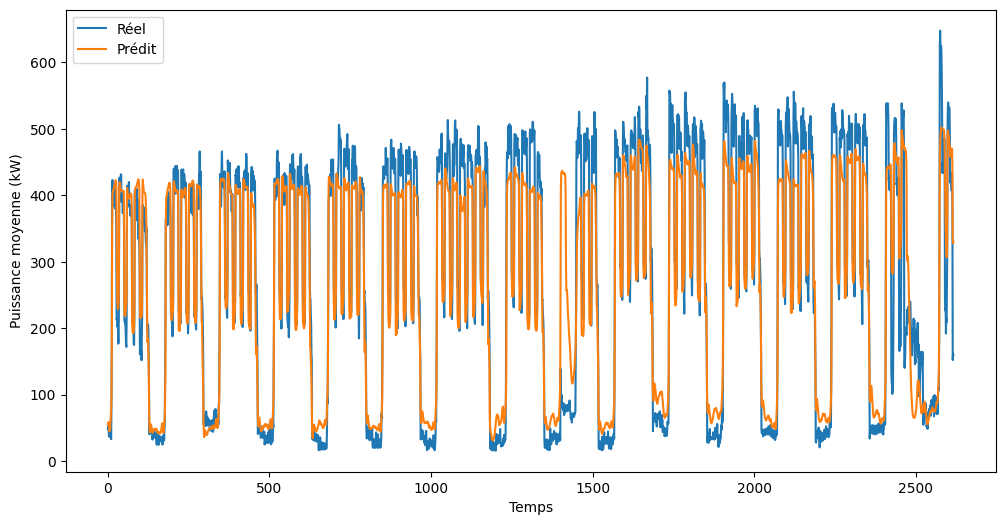

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_true, label='Réel')
plt.plot(y_pred, label='Prédit')
plt.xlabel('Temps')
plt.ylabel('Puissance moyenne (kW)')
plt.legend()
plt.show()

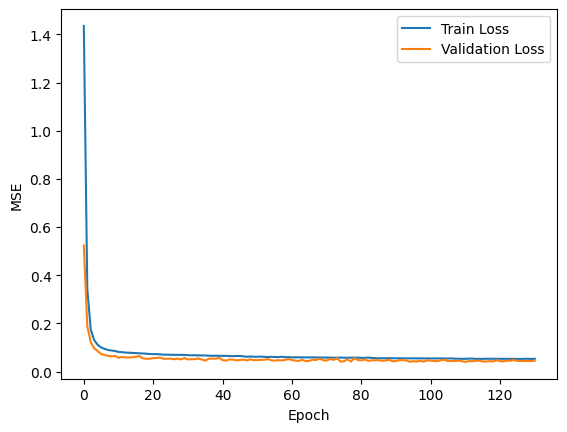

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [ ]:
# Calcul de la MAE relative (en %)
# ❗ Utiliser les valeurs réelles, pas les valeurs normalisées
mae_pct = mae / np.mean(y_true) * 100
print(f"MAE relative : {mae_pct:.2f} %")


MAE relative : 14.88 %


In [ ]:
# Vérifier les statistiques des données ORIGINALES
print("=" * 60)
print("📊 STATISTIQUES DES DONNÉES ORIGINALES")
print("=" * 60)
print(f"\nTarget (puissance) :")
print(f"  - Min    : {df['puissance'].min():.2f}")
print(f"  - Max    : {df['puissance'].max():.2f}")
print(f"  - Moyenne: {df['puissance'].mean():.2f}")
print(f"  - Médiane: {df['puissance'].median():.2f}")
print(f"  - Std    : {df['puissance'].std():.2f}")

# Vérifier les prédictions
print(f"\n\nPrédictions sur le test set :")
print(f"  - Min    : {y_pred.min():.2f}")
print(f"  - Max    : {y_pred.max():.2f}")
print(f"  - Moyenne: {y_pred.mean():.2f}")

print(f"\n\nValeurs réelles du test set :")
print(f"  - Min    : {y_true.min():.2f}")
print(f"  - Max    : {y_true.max():.2f}")
print(f"  - Moyenne: {y_true.mean():.2f}")

# Vérifier le scaler
print(f"\n\n🔧 VÉRIFICATION DU SCALER_Y :")
print(f"  - Scale : {scaler_y.scale_[0]:.10f}")
# print(f"  - Min   : {scaler_y.min_[0]:.10f}")
# print(f"  - Data min : {scaler_y.data_min_[0]:.2f}")
# print(f"  - Data max : {scaler_y.data_max_[0]:.2f}")

# Échantillon de prédictions vs réalité
print(f"\n\n📋 ÉCHANTILLON (10 premières valeurs du test) :")
print(f"{'Réel':>10} | {'Prédit':>10} | {'Erreur':>10} | {'Erreur %':>10}")
print("-" * 50)
for i in range(min(10, len(y_true))):
    err = abs(y_true[i][0] - y_pred[i][0])
    err_pct = (err / y_true[i][0]) * 100 if y_true[i][0] != 0 else 0
    print(f"{y_true[i][0]:10.2f} | {y_pred[i][0]:10.2f} | {err:10.2f} | {err_pct:9.1f}%")

📊 STATISTIQUES DES DONNÉES ORIGINALES

Target (puissance_moy_heure) :
  - Min    : 14.75
  - Max    : 647.75
  - Moyenne: 267.61
  - Médiane: 274.25
  - Std    : 171.42


Prédictions sur le test set :
  - Min    : 30.56
  - Max    : 502.04
  - Moyenne: 267.04


Valeurs réelles du test set :
  - Min    : 15.50
  - Max    : 647.75
  - Moyenne: 276.61


🔧 VÉRIFICATION DU SCALER_Y :
  - Scale : 171.4132869027


📋 ÉCHANTILLON (10 premières valeurs du test) :
      Réel |     Prédit |     Erreur |   Erreur %
--------------------------------------------------
     47.83 |      54.62 |       6.79 |      14.2%
     53.17 |      57.50 |       4.34 |       8.2%
     53.00 |      58.53 |       5.53 |      10.4%
     38.83 |      55.81 |      16.98 |      43.7%
     37.08 |      49.29 |      12.20 |      32.9%
     46.33 |      44.71 |       1.62 |       3.5%
     36.92 |      46.45 |       9.54 |      25.8%
     36.25 |      50.64 |      14.39 |      39.7%
     51.08 |      59.19 |       8.11 |   

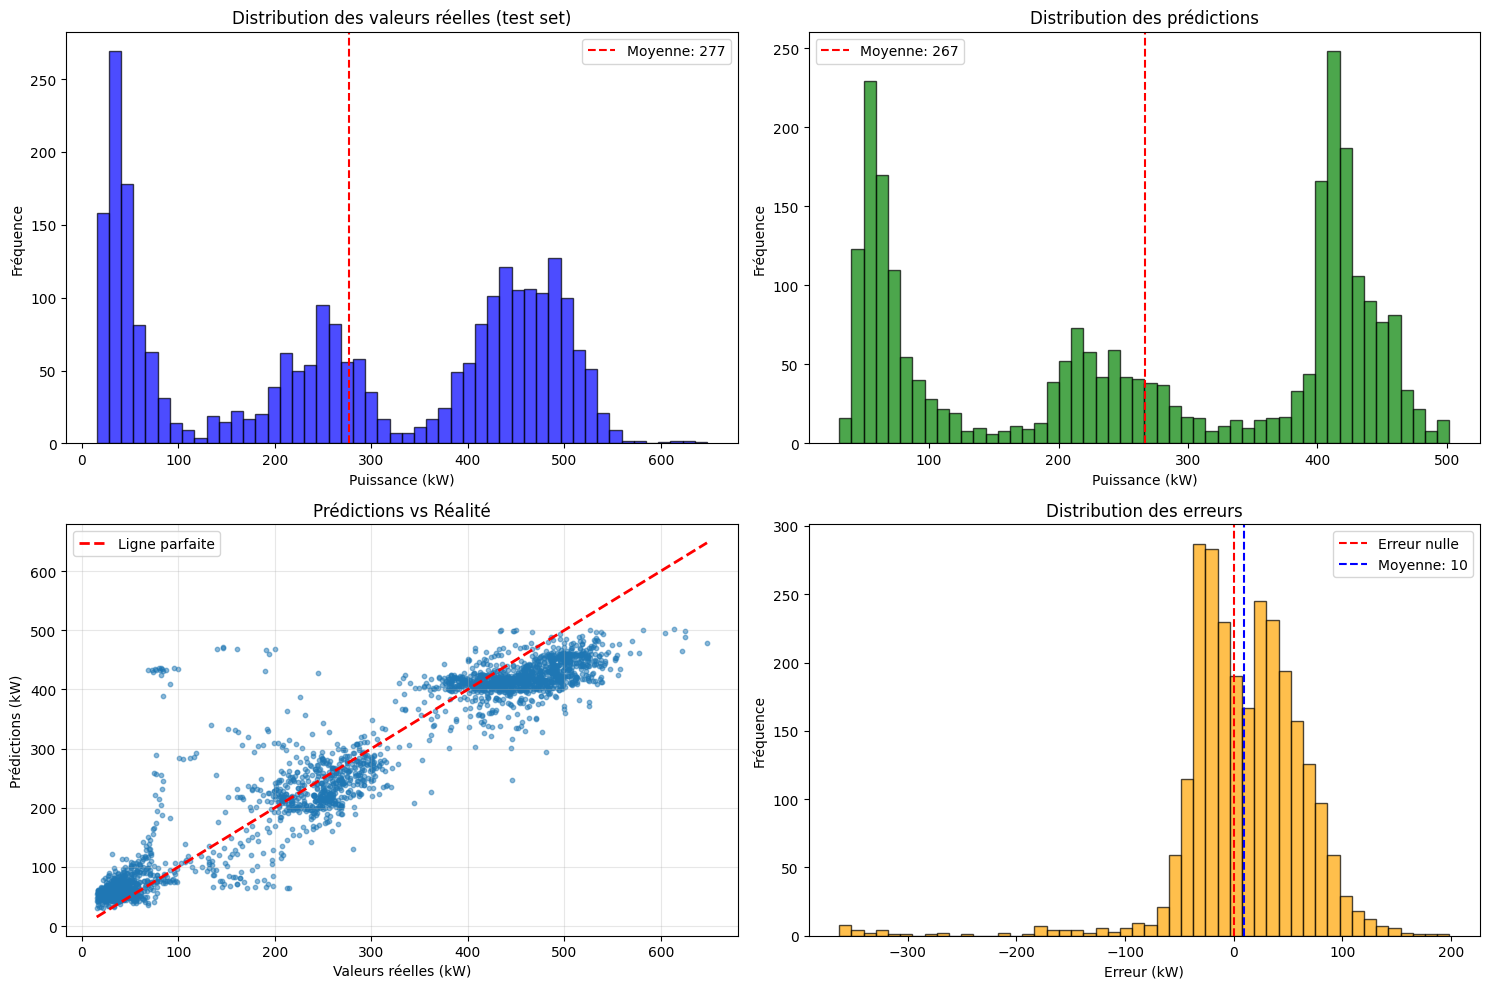


💡 Si les distributions sont complètement décalées, il y a un problème d'échelle !


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distribution des valeurs réelles
axes[0, 0].hist(y_true, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].set_title('Distribution des valeurs réelles (test set)')
axes[0, 0].set_xlabel('Puissance (kW)')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].axvline(y_true.mean(), color='red', linestyle='--', label=f'Moyenne: {y_true.mean():.0f}')
axes[0, 0].legend()

# 2. Distribution des prédictions
axes[0, 1].hist(y_pred, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].set_title('Distribution des prédictions')
axes[0, 1].set_xlabel('Puissance (kW)')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].axvline(y_pred.mean(), color='red', linestyle='--', label=f'Moyenne: {y_pred.mean():.0f}')
axes[0, 1].legend()

# 3. Scatter plot : Prédit vs Réel
axes[1, 0].scatter(y_true, y_pred, alpha=0.5, s=10)
axes[1, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Ligne parfaite')
axes[1, 0].set_title('Prédictions vs Réalité')
axes[1, 0].set_xlabel('Valeurs réelles (kW)')
axes[1, 0].set_ylabel('Prédictions (kW)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Distribution des erreurs
errors = (y_true - y_pred).flatten()
axes[1, 1].hist(errors, bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1, 1].set_title('Distribution des erreurs')
axes[1, 1].set_xlabel('Erreur (kW)')
axes[1, 1].set_ylabel('Fréquence')
axes[1, 1].axvline(0, color='red', linestyle='--', label='Erreur nulle')
axes[1, 1].axvline(errors.mean(), color='blue', linestyle='--', label=f'Moyenne: {errors.mean():.0f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"\n💡 Si les distributions sont complètement décalées, il y a un problème d'échelle !")

# Analyse d'importance des features

In [ ]:
# -----------------------
# Permutation Feature Importance
# -----------------------
# Pour chaque feature, on la permute aléatoirement et on mesure la baisse de performance

print("🔄 Calcul de l'importance des features (peut prendre quelques minutes)...")
print("=" * 70)

# MAE de référence (baseline)
y_val_pred_scaled = model.predict(X_val, verbose=0)
y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled)
y_val_true = scaler_y.inverse_transform(y_val)
baseline_mae = mean_absolute_error(y_val_true, np.clip(y_val_pred, 0, None))

print(f"MAE baseline (validation set) : {baseline_mae:.2f} kW\n")

# Calculer l'importance pour chaque feature
feature_importance = {}

for i, feature_name in enumerate(features):
    # Copier les données de validation
    X_val_permuted = X_val.copy()

    # Permuter la feature i dans toutes les séquences temporelles
    for seq_idx in range(X_val_permuted.shape[0]):
        for time_idx in range(X_val_permuted.shape[1]):
            # Permutation aléatoire de la feature à travers tous les échantillons
            perm_indices = np.random.permutation(X_val_permuted.shape[0])
            X_val_permuted[seq_idx, time_idx, i] = X_val[perm_indices[seq_idx], time_idx, i]

    # Prédire avec la feature permutée
    y_val_pred_perm_scaled = model.predict(X_val_permuted, verbose=0)
    y_val_pred_perm = scaler_y.inverse_transform(y_val_pred_perm_scaled)
    mae_permuted = mean_absolute_error(y_val_true, np.clip(y_val_pred_perm, 0, None))

    # Importance = augmentation de l'erreur après permutation
    importance = mae_permuted - baseline_mae
    feature_importance[feature_name] = importance

    print(f"✓ {feature_name:25} | MAE: {mae_permuted:6.2f} kW | Importance: {importance:+6.2f} kW")

print("\n" + "=" * 70)

🔄 Calcul de l'importance des features (peut prendre quelques minutes)...
MAE baseline (validation set) : 30.12 kW

✓ jour_sin                  | MAE:  60.91 kW | Importance: +30.79 kW
✓ heure_sin                 | MAE:  69.33 kW | Importance: +39.21 kW
✓ jour_ferie                | MAE:  42.31 kW | Importance: +12.19 kW
✓ heure_cos                 | MAE:  39.65 kW | Importance:  +9.53 kW
✓ jour_cos                  | MAE: 108.46 kW | Importance: +78.34 kW
✓ temperature               | MAE:  29.43 kW | Importance:  -0.68 kW
✓ humidite                  | MAE:  31.24 kW | Importance:  +1.12 kW
✓ temp_x_heure_cos          | MAE:  36.35 kW | Importance:  +6.23 kW
✓ temp_x_heure_sin          | MAE:  32.02 kW | Importance:  +1.90 kW
✓ puissance_roll_12         | MAE:  30.04 kW | Importance:  -0.08 kW
✓ puissance_std_24          | MAE:  30.23 kW | Importance:  +0.11 kW
✓ puissance_lag_1           | MAE:  30.69 kW | Importance:  +0.57 kW
✓ puissance_max_24          | MAE:  30.28 kW | Importance

C:\Users\36MONNIE-L\AppData\Local\Temp\ipykernel_26852\3412419096.py:44: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\36MONNIE-L\AppData\Local\Temp\ipykernel_26852\3412419096.py:44: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\venv\tf\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\venv\tf\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


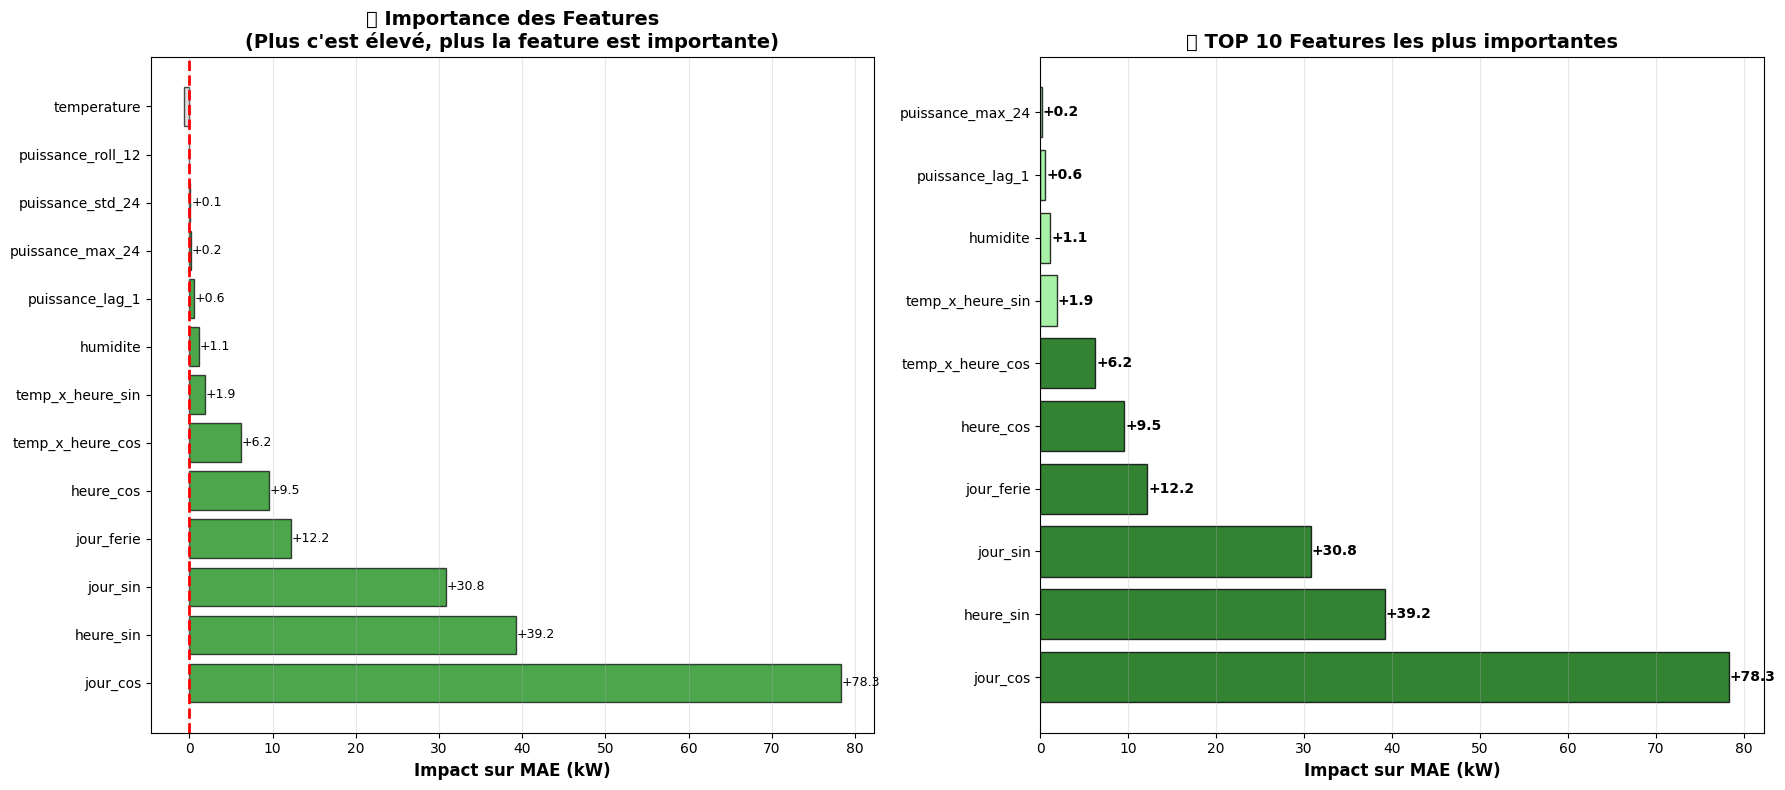


🏆 TOP 10 FEATURES LES PLUS IMPORTANTES
 1. 🔥 jour_cos                       | Impact: +78.34 kW
 2. 🔥 heure_sin                      | Impact: +39.21 kW
 3. 🔥 jour_sin                       | Impact: +30.79 kW
 4. 🔥 jour_ferie                     | Impact: +12.19 kW
 5. 🔥 heure_cos                      | Impact: + 9.53 kW
 6. 🔥 temp_x_heure_cos               | Impact: + 6.23 kW
 7. ✓ temp_x_heure_sin               | Impact: + 1.90 kW
 8. ✓ humidite                       | Impact: + 1.12 kW
 9. ✓ puissance_lag_1                | Impact: + 0.57 kW
10. ✓ puissance_max_24               | Impact: + 0.16 kW

📊 STATISTIQUES
Features avec impact positif   : 11/13
Impact moyen (features utiles) : 16.38 kW
Impact max                     : 78.34 kW
Impact total                   : 180.16 kW


In [ ]:
# -----------------------
# Visualisation de l'importance des features
# -----------------------

# Trier par importance
sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

# Extraire noms et valeurs
feature_names_sorted = [f[0] for f in sorted_features]
importance_values = [f[1] for f in sorted_features]

# Créer le graphique
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Graphique 1 : Toutes les features
colors = ['green' if imp > 0 else 'lightgray' for imp in importance_values]
bars = ax1.barh(feature_names_sorted, importance_values, color=colors, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Impact sur MAE (kW)', fontsize=12, fontweight='bold')
ax1.set_title('📊 Importance des Features\n(Plus c\'est élevé, plus la feature est importante)',
              fontsize=14, fontweight='bold')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax1.grid(axis='x', alpha=0.3)

# Ajouter les valeurs sur les barres
for i, (bar, val) in enumerate(zip(bars, importance_values)):
    if val > 0:
        ax1.text(val + 0.1, i, f'+{val:.1f}', va='center', fontsize=9)

# Graphique 2 : Top 10 features uniquement
top_10 = sorted_features[:10]
top_names = [f[0] for f in top_10]
top_values = [f[1] for f in top_10]

colors_top = ['darkgreen' if imp > 5 else 'green' if imp > 2 else 'lightgreen' for imp in top_values]
bars2 = ax2.barh(top_names, top_values, color=colors_top, edgecolor='black', alpha=0.8)
ax2.set_xlabel('Impact sur MAE (kW)', fontsize=12, fontweight='bold')
ax2.set_title('🏆 TOP 10 Features les plus importantes', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Ajouter les valeurs sur les barres
for i, (bar, val) in enumerate(zip(bars2, top_values)):
    ax2.text(val + 0.1, i, f'+{val:.1f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Afficher le résumé textuel
print("\n" + "=" * 70)
print("🏆 TOP 10 FEATURES LES PLUS IMPORTANTES")
print("=" * 70)
for i, (feat, imp) in enumerate(top_10, 1):
    category = "🔥" if imp > 5 else "⭐" if imp > 2 else "✓"
    print(f"{i:2d}. {category} {feat:30} | Impact: +{imp:5.2f} kW")

print("\n" + "=" * 70)
print("📊 STATISTIQUES")
print("=" * 70)
positive_features = [v for v in importance_values if v > 0]
print(f"Features avec impact positif   : {len(positive_features)}/{len(features)}")
print(f"Impact moyen (features utiles) : {np.mean(positive_features):.2f} kW")
print(f"Impact max                     : {max(importance_values):.2f} kW")
print(f"Impact total                   : {sum(positive_features):.2f} kW")
print("=" * 70)

In [ ]:
# ====================================================================
# SAUVEGARDE DU MODÈLE ET DES COMPOSANTS POUR PRODUCTION
# ====================================================================

import pickle
import json

print("💾 Sauvegarde du modèle pour production...")
print("=" * 80)

# 1️⃣ Sauvegarder le modèle Keras
model_path = "modele_lstm_production.h5"
model.save(model_path)
print(f"✅ Modèle sauvegardé : {model_path}")

# 2️⃣ Sauvegarder les scalers (INDISPENSABLE pour faire des prédictions)
scaler_path = "scalers_production.pkl"
with open(scaler_path, 'wb') as f:
    pickle.dump({
        'scaler_X': scaler_X,
        'scaler_y': scaler_y
    }, f)
print(f"✅ Scalers sauvegardés : {scaler_path}")

# 3️⃣ Sauvegarder la configuration (features + hyperparamètres)
config = {
    'features': features,
    'window': WINDOW,
    'lstm1_units': LSTM1_UNITS,
    'lstm2_units': LSTM2_UNITS,
    'lstm3_units': LSTM3_UNITS,
    'dropout_rate': DROPOUT_RATE,
    'l2_reg': L2_REG,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'epochs': EPOCHS,
    'target': target,
    'performance': {
        'mae': float(mae),
        'rmse': float(rmse),
        'mape': float(mape),
        'r2': float(r2)
    }
}

config_path = "config_production.json"
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=4, ensure_ascii=False)
print(f"✅ Configuration sauvegardée : {config_path}")

# 4️⃣ Sauvegarder un exemple de prédiction (pour tests)
sample_data = {
    'X_sample': X_test[0].tolist(),  # Premier échantillon du test
    'y_true': float(y_true[0][0]),
    'y_pred': float(y_pred[0][0])
}

sample_path = "sample_prediction.json"
with open(sample_path, 'w', encoding='utf-8') as f:
    json.dump(sample_data, f, indent=4)
print(f"✅ Exemple de prédiction sauvegardé : {sample_path}")

print("\n" + "=" * 80)
print("✅ TOUS LES FICHIERS NÉCESSAIRES SONT SAUVEGARDÉS !")
print("=" * 80)
print("\n📦 Fichiers créés :")
print(f"   1. {model_path:30} (Modèle LSTM)")
print(f"   2. {scaler_path:30} (Scalers pour normalisation)")
print(f"   3. {config_path:30} (Configuration + features)")
print(f"   4. {sample_path:30} (Exemple pour tests)")
print("\n💡 Ces 4 fichiers sont nécessaires pour utiliser le modèle en production.")

## 🔮 Fonction de prédiction itérative pour production

Cette fonction prédit les consommations futures en utilisant :
- Les 48 dernières heures d'historique (pour les lags et rolling features)
- Les données météo futures (température, humidité, jour férié)
- Les prédictions précédentes pour mettre à jour les features historiques

In [ ]:
import pickle
import json
from datetime import datetime, timedelta

def predict_future(model_path, scaler_X_path, scaler_y_path, config_path,
                   historique_df, meteo_future_df, horizon=24):
    """
    Prédit les consommations futures à partir de la dernière date disponible.

    Paramètres :
    -----------
    model_path : str
        Chemin vers le modèle sauvegardé (.h5)
    scaler_X_path : str
        Chemin vers le scaler des features (.pkl)
    scaler_y_path : str
        Chemin vers le scaler de la cible (.pkl)
    config_path : str
        Chemin vers la configuration du modèle (.json)
    historique_df : pd.DataFrame
        DataFrame avec au moins 48h d'historique contenant :
        - datetime : colonne temporelle
        - puissance_kw : consommation en kW
        - temperature : température (°C)
        - humidite : humidité (%)
        - jour_ferie : indicateur jour férié (0/1)
    meteo_future_df : pd.DataFrame
        DataFrame avec les données météo futures contenant :
        - datetime : colonne temporelle
        - temperature : température (°C)
        - humidite : humidité (%)
        - jour_ferie : indicateur jour férié (0/1)
    horizon : int
        Nombre d'heures à prédire

    Retourne :
    ---------
    pd.DataFrame : prédictions avec colonnes datetime et puissance_kw_pred
    """

    # 1. Charger le modèle et les scalers
    from tensorflow.keras.models import load_model
    model = load_model(model_path)

    with open(scaler_X_path, 'rb') as f:
        scaler_X = pickle.load(f)
    with open(scaler_y_path, 'rb') as f:
        scaler_y = pickle.load(f)
    with open(config_path, 'r') as f:
        config = json.load(f)

    window = config['hyperparameters']['window']
    features = config['features']

    # 2. Vérifier qu'on a assez d'historique
    if len(historique_df) < window:
        raise ValueError(f"Besoin d'au moins {window}h d'historique, {len(historique_df)}h fourni")

    # 3. Créer une copie complète des données (historique + futur)
    historique_df = historique_df.copy()
    meteo_future_df = meteo_future_df.copy()

    # S'assurer que datetime est bien en datetime
    historique_df['datetime'] = pd.to_datetime(historique_df['datetime'])
    meteo_future_df['datetime'] = pd.to_datetime(meteo_future_df['datetime'])

    # Trier par date
    historique_df = historique_df.sort_values('datetime').reset_index(drop=True)
    meteo_future_df = meteo_future_df.sort_values('datetime').reset_index(drop=True)

    # 4. Prendre les 48 dernières heures d'historique
    historique_recent = historique_df.tail(window).copy()

    # 5. Initialiser le DataFrame de travail avec l'historique
    df_work = historique_recent.copy()

    # 6. Fonction pour créer les features temporelles
    def create_temporal_features(df):
        df = df.copy()
        df['heure'] = df['datetime'].dt.hour
        df['jour'] = df['datetime'].dt.dayofweek

        # Features cycliques
        df['heure_sin'] = np.sin(2 * np.pi * df['heure'] / 24)
        df['heure_cos'] = np.cos(2 * np.pi * df['heure'] / 24)
        df['jour_sin'] = np.sin(2 * np.pi * df['jour'] / 7)
        df['jour_cos'] = np.cos(2 * np.pi * df['jour'] / 7)

        return df

    # 7. Fonction pour créer les features historiques
    def create_historical_features(df):
        df = df.copy()

        # Lags
        df['puissance_lag_1'] = df['puissance_kw'].shift(1)

        # Rolling statistics
        df['puissance_roll_12'] = df['puissance_kw'].rolling(window=12, min_periods=1).mean()
        df['puissance_std_24'] = df['puissance_kw'].rolling(window=24, min_periods=1).std()
        df['puissance_max_24'] = df['puissance_kw'].rolling(window=24, min_periods=1).max()

        return df

    # 8. Fonction pour créer les interactions
    def create_interaction_features(df):
        df = df.copy()
        df['temp_x_heure_sin'] = df['temperature'] * df['heure_sin']
        df['temp_x_heure_cos'] = df['temperature'] * df['heure_cos']
        return df

    # 9. Créer les features pour l'historique
    df_work = create_temporal_features(df_work)
    df_work = create_historical_features(df_work)
    df_work = create_interaction_features(df_work)

    # 10. Boucle de prédiction itérative
    predictions = []

    for i in range(horizon):
        # Obtenir la dernière fenêtre de 48h
        window_data = df_work.tail(window).copy()

        # Vérifier que toutes les features sont disponibles
        missing_cols = [f for f in features if f not in window_data.columns]
        if missing_cols:
            print(f"⚠️ Colonnes manquantes : {missing_cols}")
            break

        # Sélectionner les features dans le bon ordre
        X_window = window_data[features].values

        # Gérer les NaN (remplacer par 0)
        X_window = np.nan_to_num(X_window, nan=0.0)

        # Normaliser
        X_window_scaled = scaler_X.transform(X_window)

        # Reshape pour le modèle (1, window, n_features)
        X_window_seq = X_window_scaled.reshape(1, window, len(features))

        # Prédire
        y_pred_scaled = model.predict(X_window_seq, verbose=0)
        y_pred = scaler_y.inverse_transform(y_pred_scaled)[0, 0]

        # Clipper les valeurs négatives
        y_pred = max(0, y_pred)

        # Ajouter la prédiction à la liste
        next_datetime = meteo_future_df.iloc[i]['datetime']
        predictions.append({
            'datetime': next_datetime,
            'puissance_kw_pred': y_pred
        })

        # Créer une nouvelle ligne avec la prédiction
        new_row = {
            'datetime': next_datetime,
            'puissance_kw': y_pred,  # Utiliser la prédiction comme valeur
            'temperature': meteo_future_df.iloc[i]['temperature'],
            'humidite': meteo_future_df.iloc[i]['humidite'],
            'jour_ferie': meteo_future_df.iloc[i]['jour_ferie']
        }

        # Ajouter la nouvelle ligne au DataFrame de travail
        new_row_df = pd.DataFrame([new_row])
        df_work = pd.concat([df_work, new_row_df], ignore_index=True)

        # Recalculer les features temporelles et historiques
        df_work = create_temporal_features(df_work)
        df_work = create_historical_features(df_work)
        df_work = create_interaction_features(df_work)

    # 11. Créer le DataFrame de résultats
    df_predictions = pd.DataFrame(predictions)

    print(f"✅ {len(df_predictions)} prédictions générées")
    print(f"📅 Période : {df_predictions['datetime'].min()} → {df_predictions['datetime'].max()}")
    print(f"📊 Consommation prédite : {df_predictions['puissance_kw_pred'].min():.2f} - {df_predictions['puissance_kw_pred'].max():.2f} kW")
    print(f"📊 Moyenne : {df_predictions['puissance_kw_pred'].mean():.2f} kW")

    return df_predictions


# Exemple d'utilisation :
# ========================
#
# # 1. Charger l'historique (au moins 48h)
# historique = pd.read_csv('historique_consommation.csv')
#
# # 2. Charger les données météo futures
# meteo_future = pd.read_csv('meteo_previsions_15jours.csv')
#
# # 3. Prédire les 360 prochaines heures (15 jours)
# predictions = predict_future(
#     model_path='model_optimal.h5',
#     scaler_X_path='scalers.pkl',
#     scaler_y_path='scalers.pkl',
#     config_path='model_config.json',
#     historique_df=historique,
#     meteo_future_df=meteo_future,
#     horizon=360
# )
#
# # 4. Sauvegarder les prédictions
# predictions.to_csv('predictions_15jours.csv', index=False)

print("📦 Fonction predict_future() créée avec succès !")